# Chapter 27 — VLF & the Ionosphere (SuperSID) (optional)

!!! info "Before you start"
    **Prerequisites:** Ch 5 (Hands-on SDR) · **Maths Lab:** [Lab C (Noise Statistics & RFI Excision)](33_mathslab_noise_rfi.ipynb) · **~40 min** · **Intermediate**

> **This chapter is OPTIONAL and hardware-flavoured**, in the spirit of
> [Chapter 5 (Hands-on SDR)](05_sdr_basics.ipynb),
> [Chapter 6 (Hydrogen Line)](06_hydrogen_line.ipynb), and
> [Chapter 26 (Meteor Scatter)](26_meteor_scatter.ipynb). It points at one of the
> *cheapest, most patient* real experiments in amateur radio astronomy: watching
> the Sun flare by listening to a radio station thousands of kilometres away. You
> can do it for real with a **SuperSID** pre-amp, a ~1 m loop antenna, and a
> sound card — but you need **no hardware and no network** to work through this
> chapter. Every cell runs end-to-end on the plain `jansky` base environment
> using the simulation in `jansky.vlf`. The one real-hardware recipe is clearly
> marked and never required.

Most of this course chases signals from *space*. This chapter is sneakier: we
never point at the sky at all. Instead we listen to a **very-low-frequency
(VLF, 3–30 kHz)** transmitter built by a navy for submarine communication, and
we watch its received amplitude wobble. That wobble is the **ionosphere**
breathing — and when a **solar flare** erupts 150 million km away, the wobble
jumps within minutes. We will have detected a flare on the Sun from a desk
indoors, day or night, with parts that cost less than a dish.

## What you'll learn

- Why a **VLF** signal travels halfway around the planet in the
  **Earth–ionosphere waveguide**, bouncing between the ground and the ionospheric
  **D-layer**, and why its received amplitude is a *direct readout* of that
  D-layer.
- The named VLF beacons amateurs monitor — **NAA** (Cutler, Maine, 24.0 kHz),
  **NWC** (Australia, 19.8 kHz), **GQD** (UK, 22.1 kHz) — and how their amplitude
  tracks day/night and solar activity.
- What a **sudden ionospheric disturbance (SID)** is: a flare's X-rays ionise the
  D-layer in minutes, the signal jumps, then recovers over tens of minutes — the
  same flares that drive the solar radio bursts of
  [Chapter 23](23_solar_and_jupiter.ipynb).
- How to **detect** SIDs in a day of monitoring: de-trend the slow day/night
  baseline, threshold the residual, and compare detected onsets to the truth.
- A brief tour of **natural VLF radio** — sferics, tweeks, and whistlers — and
  the [INSPIRE](https://theinspireproject.org/) project that lets you *hear* the
  magnetosphere.

Everything runs **fully offline** using `jansky.vlf`. The science (the diurnal
baseline, the SID profile, the detector) lives in that helper module; we seed
every random draw so the chapter is reproducible. No transmitter, no antenna,
no network.

This chapter pairs with the **VLF & the ionosphere** entries in
[`docs/projects.md`](../docs/projects.md) (the SuperSID kit and the INSPIRE
project) and the amateur wisdom in
[`docs/field-notes.md`](../docs/field-notes.md) — including the reminder that
radio astronomy is always **receive-only**: no licence required.

## 1. Orientation — VLF in the Earth–ionosphere waveguide

### The waveguide between the ground and the sky

At everyday radio frequencies a wave shoots off into space or gets absorbed.
**Very-low-frequency** waves (3–30 kHz, wavelengths of **10–100 km**) do
something stranger: they get *trapped*. The conducting **ground** below and the
conducting **ionosphere** above form the two walls of a planet-sized
**waveguide**, and a VLF wave skips along between them with remarkably little
loss — a single transmitter can be heard a third of the way around the Earth.
That is exactly why navies built VLF stations: the long, stable, ground-hugging
path even reaches a few metres *underwater*, so a submerged submarine can receive
orders.

The **top wall** of the waveguide is the ionosphere's lowest layer, the
**D-region**, at roughly **60–90 km** altitude. And here is the crucial point for
us: that wall is not fixed. The D-layer exists because solar **ultraviolet and
X-ray** radiation ionises the thin air up there. So:

- **By day**, sunlight keeps the D-layer ionised; the waveguide ceiling is firm
  and relatively *low*. The received VLF amplitude settles to its daytime value.
- **At night**, with no sunlight, the D-layer **recombines and largely vanishes**;
  the effective ceiling rises and changes character. The amplitude (and phase)
  shifts to a different nighttime value.
- At **dawn and dusk** — when the sunrise/sunset *terminator* sweeps across the
  propagation path — the amplitude swings smoothly between the two. This is the
  diurnal variation we will simulate in Section 2.

Monitor a distant VLF carrier's amplitude and you are, in effect, running a
**continuous measurement of the D-layer overhead**. The transmitter is your
free, always-on probe.

### The transmitters you can monitor

You do not transmit anything — you listen to powerful beacons that are *always
on*. A few that amateurs around the world track:

| Call | Frequency | Location | Notes |
|------|-----------|----------|-------|
| **NAA** | 24.0 kHz | Cutler, Maine, USA | One of the strongest; classic for North America |
| **NLK** | 24.8 kHz | Jim Creek, Washington, USA | West-coast US workhorse |
| **NWC** | 19.8 kHz | Exmouth, Australia | Dominant beacon for the Pacific / Asia |
| **GQD** | 22.1 kHz | Anthorn, UK | A good European target |
| **DHO38** | 23.4 kHz | Rhauderfehn, Germany | Strong across Europe |

You pick a transmitter whose great-circle path to you is long enough that the
signal genuinely *samples* the ionosphere (a few hundred to a few thousand km is
ideal), and whose amplitude is strong and steady. Its received level then traces
the day/night cycle — and, superimposed on that, the sudden jumps when the Sun
flares.

### The SuperSID monitor (the real hardware)

> **Real-hardware path — not required for this notebook.**
>
> A **SuperSID** station is about as simple as radio astronomy gets:
>
> - a **~1 m loop antenna** (often just a coil of wire on a square frame) tuned
>   to the VLF band — it picks up the *magnetic* component of the wave and is
>   wonderfully immune to local electric noise;
> - a small **pre-amplifier** to lift the tiny induced voltage;
> - your computer's **sound card** as the receiver — VLF (a few to tens of kHz)
>   falls *inside the audio band*, so a 96 kHz sound card samples it directly,
>   no SDR needed;
> - free software that runs an FFT and logs the amplitude of each chosen
>   transmitter, 24/7.
>
> It runs **indoors**, day and night, unattended, for years. And because radio
> astronomy is **receive-only**, **no licence is required** (see the
> [field notes](../docs/field-notes.md) — *"it's always legal to listen"*). The
> SuperSID project is run by the **Stanford SOLAR Center** with **SARA**; the
> kit and full instructions are in
> [`docs/projects.md`](../docs/projects.md#vlf-the-ionosphere).

In the rest of this chapter we **simulate** exactly what such a station records:
a day of received amplitude, with the diurnal baseline, a couple of flares, and
noise — and then we detect the flares.

## Setup

We import the VLF toolkit from `jansky.vlf` and the course plotting style. We
**do not re-implement** the SID profile, the day simulator, or the detector —
every numerical step below calls a helper from that module:

- `sid_profile(t_hours, onset, amplitude, ...)` — the shape of one flare's
  enhancement: a fast rise then a slow exponential recovery;
- `simulate_vlf_day(flares, diurnal_amp, noise, seed)` — 24 h of received
  amplitude = diurnal baseline + flares + noise; returns
  `(hours, signal, true_onsets)`;
- `detect_sids(hours, signal, threshold, ...)` — de-trends the diurnal baseline
  with a running median and flags threshold-crossing excursions, returning a
  `SIDDetection` dataclass (`.onsets`, `.count`).

We seed every random draw with `jansky.signals.rng` so the chapter is
reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jansky.plotting import use_jansky_style, show_image
from jansky.signals import rng
from jansky.vlf import sid_profile, simulate_vlf_day, detect_sids, SIDDetection

use_jansky_style()
SEED = 27
generator = rng(SEED)  # one seeded generator for the whole chapter

# A reproducible "observing day": two flares (onset hour, strength).
FLARES = [(9.5, 6.0), (14.2, 10.0)]   # (UT hour, amplitude in signal units)
print("VLF monitoring day configured:")
for onset, amp in FLARES:
    print(f"  flare at {onset:5.2f} h UT, amplitude {amp:4.1f}")


VLF monitoring day configured:
  flare at  9.50 h UT, amplitude  6.0
  flare at 14.20 h UT, amplitude 10.0


## 2. A day of VLF

Let us record a full day. `simulate_vlf_day` builds 24 h of received amplitude on
a fine time grid (default **240 samples/hour ≈ one every 15 s**, just like a real
SuperSID log) out of three ingredients:

1. a smooth **diurnal baseline** — the slow day/night swing as the D-layer
   appears at dawn and fades at dusk (`diurnal_amp` sets how deep the swing is);
2. each **flare**, added through `sid_profile` (Section 3);
3. **measurement noise** (`noise`), the receiver/antenna hiss.

It returns the time axis (`hours`, 0–24), the `signal`, and the array of *true*
flare onset hours we will try to recover later.

In [2]:
hours, signal, true_onsets = simulate_vlf_day(
    flares=FLARES,
    diurnal_amp=3.0,   # depth of the slow day/night swing
    noise=0.3,         # measurement-noise sigma
    seed=SEED,
)

print(f"recorded {signal.size:,} samples over {hours[-1] + (hours[1]-hours[0]):.0f} h "
      f"({1/(hours[1]-hours[0]):.0f} samples/hour ~ every "
      f"{(hours[1]-hours[0])*3600:.0f} s)")
print(f"amplitude range: {signal.min():.2f} to {signal.max():.2f}")
print(f"true flare onsets: {', '.join(f'{o:.2f} h' for o in true_onsets)}")


recorded 5,760 samples over 24 h (240 samples/hour ~ every 15 s)
amplitude range: 6.02 to 19.65
true flare onsets: 9.50 h, 14.20 h


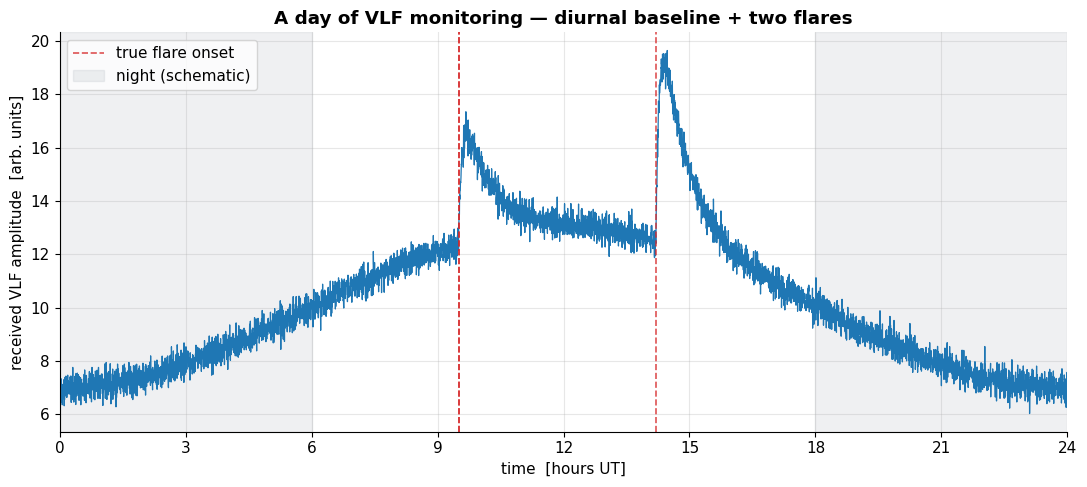

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hours, signal, color="#1f77b4", lw=0.9)

# Mark the true flare onsets.
for o in true_onsets:
    ax.axvline(o, color="#d62728", ls="--", lw=1.2, alpha=0.8)
ax.axvline(true_onsets[0], color="#d62728", ls="--", lw=1.2, alpha=0.8,
           label="true flare onset")

# Shade "night" (schematic): low D-layer ionisation away from local midday.
ax.axvspan(0, 6, color="#34495e", alpha=0.08)
ax.axvspan(18, 24, color="#34495e", alpha=0.08, label="night (schematic)")

ax.set_xlabel("time  [hours UT]")
ax.set_ylabel("received VLF amplitude  [arb. units]")
ax.set_title("A day of VLF monitoring — diurnal baseline + two flares")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


Two completely different *kinds* of variation share this plot, and telling
them apart is the whole game:

- The **smooth, slow rise and fall** across the day is the **diurnal baseline** —
  the D-layer forming at dawn and dissolving at dusk as the terminator crosses the
  path. It takes *hours* and is perfectly ordinary; it is the ionosphere's
  daily breathing.
- The **sharp upward spikes** (here near 9.5 h and 14.2 h) are **flares**: a
  jump in *minutes*, far faster than anything the day/night cycle can do, then a
  slow sag back to the baseline. Those are sudden ionospheric disturbances — the
  Sun announcing itself.

The detector in Section 4 exploits exactly this timescale gap: remove the slow
baseline, and only the fast flare spikes survive.

## 3. The SID profile

Zoom in on what one flare does to the signal. When a solar flare erupts, it
floods the dayside Earth with a burst of **soft X-rays**. Those X-rays penetrate
to ~70–90 km and **suddenly ionise the D-layer** far more than sunlight alone —
the waveguide's top wall becomes a much better reflector almost at once. The
received VLF amplitude therefore **jumps within a few minutes** (the X-ray flux
rises fast), then **recovers over tens of minutes** as the extra ionisation
recombines once the flare subsides.

`sid_profile(t_hours, onset, amplitude, rise_min, decay_min)` captures exactly
that asymmetry:

$$
A(t) \;=\; A_0 \,\bigl(1 - e^{-\Delta t / \tau_{\text{rise}}}\bigr)\,
            e^{-\Delta t / \tau_{\text{decay}}}, \qquad \Delta t = t - t_{\text{onset}},
$$

with a **fast** rise time $\tau_{\text{rise}}\!\approx\!5$ min and a **slow**
decay $\tau_{\text{decay}}\!\approx\!40$ min. The product of a saturating rise and
an exponential decay gives the characteristic shark-fin shape: steep up, gentle
down.

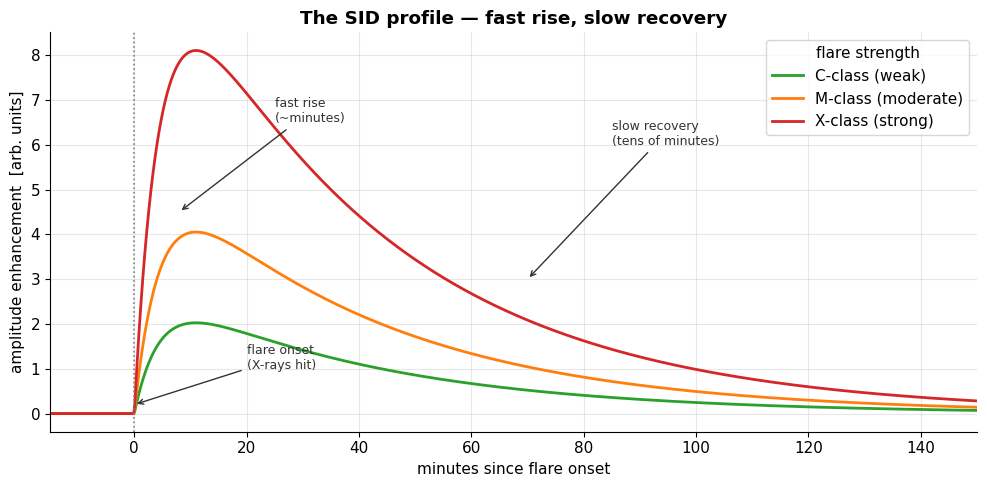

In [4]:
t = np.linspace(0, 3, 1000)   # 3 hours, flare onset at t = 0.5 h
onset = 0.5

fig, ax = plt.subplots(figsize=(10, 5))
for amp, cls, col in [(3.0, "C-class (weak)", "#2ca02c"),
                      (6.0, "M-class (moderate)", "#ff7f0e"),
                      (12.0, "X-class (strong)", "#d62728")]:
    prof = sid_profile(t, onset=onset, amplitude=amp)
    ax.plot((t - onset) * 60, prof, lw=2, color=col, label=cls)

ax.axvline(0, color="#7f7f7f", ls=":", lw=1.2)
ax.annotate("flare onset\n(X-rays hit)", xy=(0, 0.2), xytext=(20, 1.0),
            fontsize=9, color="#333333",
            arrowprops=dict(arrowstyle="->", color="#333333"))
ax.annotate("fast rise\n(~minutes)", xy=(8, 4.5), xytext=(25, 6.5), fontsize=9,
            color="#333333", arrowprops=dict(arrowstyle="->", color="#333333"))
ax.annotate("slow recovery\n(tens of minutes)", xy=(70, 3.0), xytext=(85, 6.0),
            fontsize=9, color="#333333",
            arrowprops=dict(arrowstyle="->", color="#333333"))
ax.set_xlabel("minutes since flare onset")
ax.set_ylabel("amplitude enhancement  [arb. units]")
ax.set_title("The SID profile — fast rise, slow recovery")
ax.legend(title="flare strength")
ax.set_xlim(-15, 150)
plt.tight_layout()
plt.show()


**Flare class and amplitude.** Solar flares are graded by their peak soft
X-ray flux: **B**, **C**, **M**, **X**, each step a *factor of ten* brighter than
the last (and a number 1–9 within each). A **C-class** flare is a routine event;
**M-class** is moderate (and may disturb radio and GPS on the dayside);
**X-class** is a major flare that can spark aurorae and space-weather alerts. A
stronger flare deposits more X-ray energy, ionises the D-layer harder, and so
produces a **larger** VLF amplitude jump and often a **faster** rise. We model
that here purely as a bigger `amplitude`: the curves above stand in,
conceptually, for C/M/X events.

**The connection to Chapter 23.** This is the *same* flare physics that powers
the solar radio bursts of [Chapter 23](23_solar_and_jupiter.ipynb). There, a
flare's accelerated electrons and CME shock light up the corona as **type II/III
bursts** at ~20 MHz; here, the *same* flare's X-rays reach down and rattle our
own D-layer. A SuperSID station and a Radio JOVE station, watching the same
flare, see two different fingerprints of one event — solar radio astronomy from
two angles.

## 4. Detecting flares

Now the payoff: find the flares automatically, the way a real monitoring station
flags candidate events. `detect_sids` does two things:

1. **De-trend.** It removes the slow diurnal baseline with a **running-median**
   filter (over a ~2 h window). The median is robust: it follows the gentle
   day/night swing but ignores the brief flare spikes, so subtracting it leaves a
   flat residual with the flares sticking up. *You must remove the baseline first*
   — otherwise the daytime hump alone would trip any fixed threshold.
2. **Threshold.** It estimates the residual noise from the **median absolute
   deviation** (robust against the flares themselves) and flags samples that
   exceed `threshold × σ`. Nearby crossings are merged into one event, reported at
   the **rise onset** (the first crossing).

In [5]:
det = detect_sids(hours, signal, threshold=5.0)

print(f"detected {det.count} SID event(s)")
print(f"  detected onsets : {', '.join(f'{o:.2f} h' for o in det.onsets)}")
print(f"  true onsets     : {', '.join(f'{o:.2f} h' for o in true_onsets)}")
print()
# Match each true flare to the nearest detection.
for o in true_onsets:
    if det.onsets.size:
        nearest = det.onsets[np.argmin(np.abs(det.onsets - o))]
        print(f"  true {o:5.2f} h  ->  detected {nearest:5.2f} h  "
              f"(off by {abs(nearest-o)*60:4.1f} min)")


detected 2 SID event(s)
  detected onsets : 9.58 h, 14.24 h
  true onsets     : 9.50 h, 14.20 h

  true  9.50 h  ->  detected  9.58 h  (off by  4.7 min)
  true 14.20 h  ->  detected 14.24 h  (off by  2.2 min)


The detected onsets land within a few minutes of the truth — the small lag
is honest: the detector fires when the rising signal *crosses the threshold*,
which is necessarily a little **after** the true onset (the signal needs a moment
to climb). A real station has the same lag, and observers note it when reporting
timings.

Let us visualise the de-trending that makes this work.

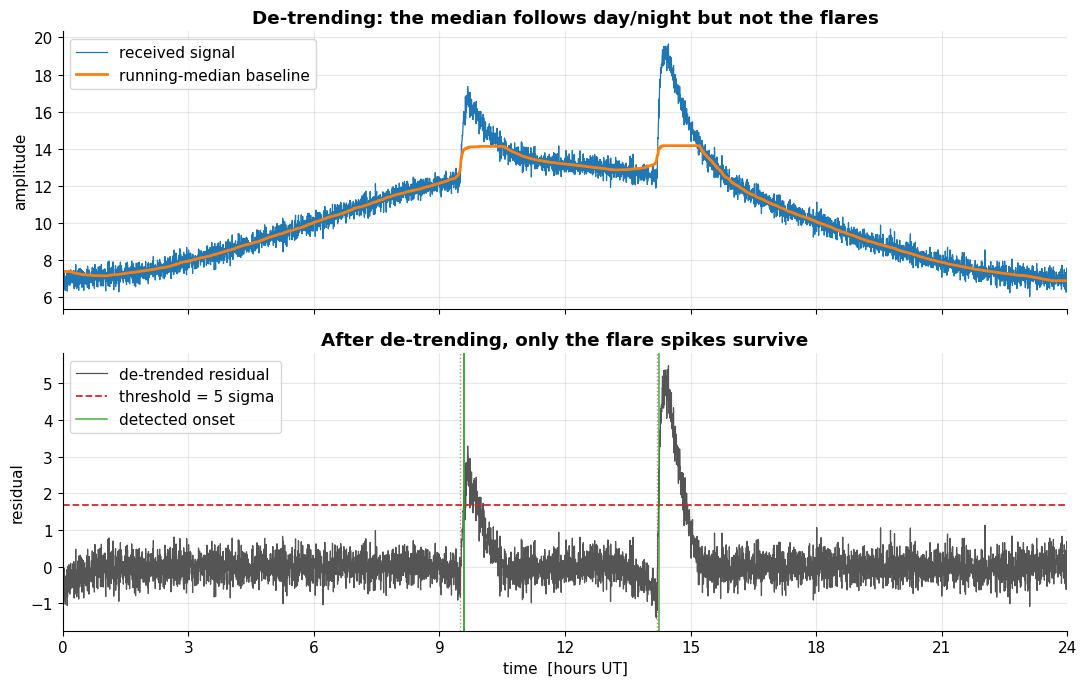

In [6]:
from scipy.ndimage import median_filter

# Reproduce the detector's de-trending so we can see it.
dt = hours[1] - hours[0]
win = max(3, int(2.0 / dt) | 1)            # ~2 h odd window, same as detect_sids
baseline_est = median_filter(signal, size=win, mode="nearest")
detrended = signal - baseline_est
mad = np.median(np.abs(detrended - np.median(detrended)))
sigma = 1.4826 * mad
threshold = 5.0

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Top: signal + the running-median baseline it removes.
axes[0].plot(hours, signal, color="#1f77b4", lw=0.9, label="received signal")
axes[0].plot(hours, baseline_est, color="#ff7f0e", lw=2,
             label="running-median baseline")
axes[0].set_ylabel("amplitude")
axes[0].set_title("De-trending: the median follows day/night but not the flares")
axes[0].legend(loc="upper left")

# Bottom: de-trended residual + threshold + detections.
axes[1].plot(hours, detrended, color="#555555", lw=0.9, label="de-trended residual")
axes[1].axhline(threshold * sigma, color="#d62728", ls="--", lw=1.3,
                label=f"threshold = {threshold:.0f} sigma")
for o in det.onsets:
    axes[1].axvline(o, color="#2ca02c", lw=1.2, alpha=0.8)
axes[1].axvline(det.onsets[0] if det.onsets.size else np.nan, color="#2ca02c",
                lw=1.2, alpha=0.8, label="detected onset")
for o in true_onsets:
    axes[1].axvline(o, color="#d62728", ls=":", lw=1.0, alpha=0.6)
axes[1].set_xlabel("time  [hours UT]")
axes[1].set_ylabel("residual")
axes[1].set_title("After de-trending, only the flare spikes survive")
axes[1].legend(loc="upper left")
axes[1].set_xlim(0, 24)
axes[1].set_xticks(range(0, 25, 3))
plt.tight_layout()
plt.show()


### The threshold trade-off

The threshold is a dial between **sensitivity** and **false alarms**. Too low and
noise bumps masquerade as flares; too high and weak (C-class) flares slip through.
Let us sweep it on our day.

In [7]:
print(f"{'threshold [sigma]':>18} {'# detected':>12}   detected onsets")
for thr in (2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 12.0):
    d = detect_sids(hours, signal, threshold=thr)
    onsets_str = ", ".join(f"{o:.2f}" for o in d.onsets) if d.count else "(none)"
    print(f"{thr:18.1f} {d.count:12d}   {onsets_str}")

print("\nLow threshold -> noise sneaks in as spurious events;")
print("high threshold -> only the strongest flares survive. The middle")
print("(~4-6 sigma) cleanly recovers the two real flares.")


 threshold [sigma]   # detected   detected onsets
               2.0           16   1.08, 2.17, 3.56, 4.83, 7.22, 8.38, 9.53, 10.96, 11.85, 14.22, 16.35, 18.01, 18.63, 19.54, 21.13, 22.68
               3.0            6   9.55, 14.23, 18.01, 19.54, 20.25, 22.03
               4.0            2   9.56, 14.23
               5.0            2   9.58, 14.24
               6.0            2   9.58, 14.24
               8.0            2   9.62, 14.25
              12.0            1   14.28

Low threshold -> noise sneaks in as spurious events;
high threshold -> only the strongest flares survive. The middle
(~4-6 sigma) cleanly recovers the two real flares.


### A quiet day yields no detections

The acid test of a detector is that it stays **silent when nothing happens**.
Simulate a day with **no flares at all** — just the diurnal baseline and noise —
and confirm a sensible threshold finds zero SIDs.

quiet day: 0 true flares, 0 detected at 5 sigma  -> PASS (no false alarms)


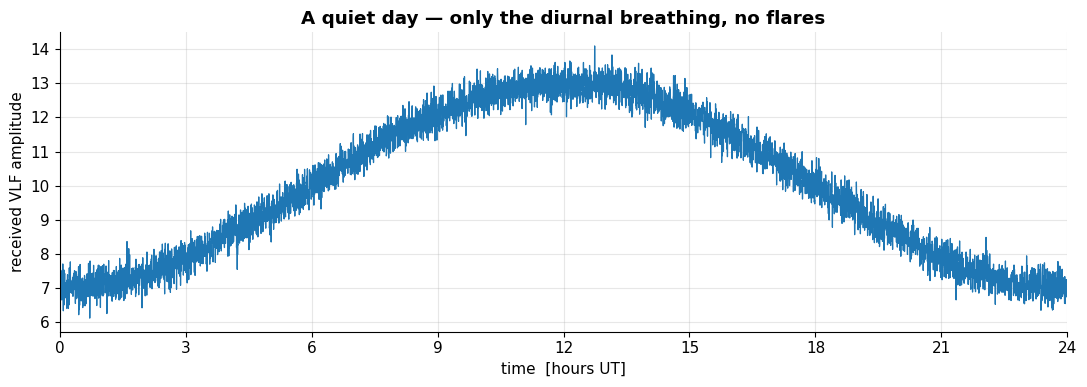

In [8]:
hours_q, signal_q, onsets_q = simulate_vlf_day(
    flares=[],          # a flare-free day
    diurnal_amp=3.0,
    noise=0.3,
    seed=SEED + 1,
)
det_quiet = detect_sids(hours_q, signal_q, threshold=5.0)
print(f"quiet day: {len(onsets_q)} true flares, "
      f"{det_quiet.count} detected at 5 sigma  -> "
      f"{'PASS (no false alarms)' if det_quiet.count == 0 else 'FALSE ALARM'}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hours_q, signal_q, color="#1f77b4", lw=0.9)
ax.set_xlabel("time  [hours UT]")
ax.set_ylabel("received VLF amplitude")
ax.set_title("A quiet day — only the diurnal breathing, no flares")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
plt.tight_layout()
plt.show()


**This is real, contributable science.** SuperSID observers around the
world log these flare timings and feed them to **space-weather** efforts: the
Stanford SOLAR Center collates SID reports, and the data complement the
**GOES** satellites' X-ray monitors — a ground-based, distributed flare watch
that keeps running even when a single instrument is down. A flare you catch from
your desk is a data point in a worldwide record. See
[`docs/projects.md`](../docs/projects.md#vlf-the-ionosphere) for how to join.

## 5. Natural VLF — sferics, tweeks, and whistlers (the INSPIRE project)

So far we have listened to a *man-made* carrier. But the VLF band is also alive
with **natural radio** — radio you can plug into headphones and literally *hear*,
because VLF lies inside the audio range. Nearly all of it is powered by
**lightning**: every stroke is a broadband electromagnetic impulse, and the
Earth–ionosphere waveguide guides that energy for thousands of kilometres. Three
classic sounds:

- **Sferics** — sharp *clicks* and *pops*, the raw impulse from nearby lightning
  arriving almost undispersed. A thunderstorm a few hundred km away crackles
  steadily.
- **Tweeks** — sferics from *distant* storms that have bounced many times down the
  night-time waveguide. Near the waveguide's cutoff (~1.7 kHz) the higher
  frequencies travel slightly faster, so the tail of the click stretches into a
  brief, musical *"tweek"* — a descending ping lasting a few milliseconds.
- **Whistlers** — the showpiece. Lightning energy that leaks *up* through the
  ionosphere can become trapped on a geomagnetic **field line** and travel along
  it out into the magnetosphere and back — sometimes to the opposite hemisphere.
  The plasma **disperses** it strongly: high frequencies arrive first, low
  frequencies seconds later, so you hear a long, eerie **descending whistle**.
  The whistler's glide *is* a probe of the plasma density along the field line —
  natural radio astronomy of the magnetosphere.

The **[INSPIRE project](https://theinspireproject.org/)** built simple VLF
receivers exactly to let students record and hear these (see
[`docs/projects.md`](../docs/projects.md#vlf-the-ionosphere)). It is the natural
companion to a SuperSID station: same band, same loop-antenna idea, but pointed
at the magnetosphere's own voice instead of a navy beacon. Best done **away from
mains hum** (the 50/60 Hz buzz and its harmonics are the enemy).

To make the idea concrete, here is a **simulated whistler**: a tone whose
frequency sweeps *downward* over a couple of seconds, the way real dispersion
draws it on a spectrogram. (Pure illustration — no detection science here.)

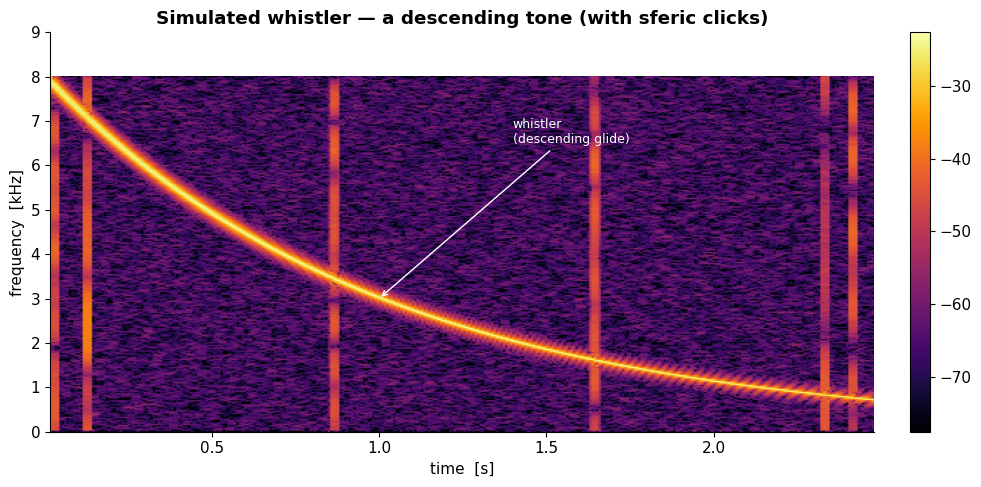

In [9]:
from scipy.signal import spectrogram

fs = 16000           # audio sample rate [Hz] — a sound card easily does VLF
duration = 2.5       # seconds
t_audio = np.linspace(0, duration, int(fs * duration), endpoint=False)

# Whistler dispersion: f(t) sweeps DOWN. A simple cold-plasma whistler has
# arrival time ~ 1/sqrt(f), so invert that for an illustrative descending glide.
f_hi, f_lo = 8000.0, 700.0
# instantaneous frequency gliding from f_hi down to f_lo
f_inst = f_hi * (f_lo / f_hi) ** (t_audio / duration)
phase = 2 * np.pi * np.cumsum(f_inst) / fs
whistler = np.sin(phase) * np.exp(-t_audio / (duration * 1.2))   # fading tail

# Sprinkle a few "sferic" clicks (broadband impulses) for atmosphere.
click_gen = rng(SEED + 2)
audio = whistler.copy()
for _ in range(6):
    i0 = click_gen.integers(0, t_audio.size)
    audio[i0:i0 + 20] += click_gen.normal(0, 2.0, size=min(20, t_audio.size - i0))

# Add gentle background hiss.
audio += generator.normal(0, 0.05, size=audio.size)

f_spec, t_spec, Sxx = spectrogram(audio, fs=fs, nperseg=512, noverlap=400)
Sxx_db = 10 * np.log10(Sxx + 1e-12)

fig, ax = plt.subplots(figsize=(10, 5))
extent = [t_spec[0], t_spec[-1], f_spec[0] / 1000, f_spec[-1] / 1000]
show_image(Sxx_db, ax=ax, aspect="auto", extent=extent,
           vmin=Sxx_db.max() - 55, vmax=Sxx_db.max(),
           title="Simulated whistler — a descending tone (with sferic clicks)")
ax.set_xlabel("time  [s]")
ax.set_ylabel("frequency  [kHz]")
ax.set_ylim(0, 9)
ax.grid(False)
ax.annotate("whistler\n(descending glide)", xy=(1.0, 3.0), xytext=(1.4, 6.5),
            color="white", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="white"))
plt.tight_layout()
plt.show()


On a real INSPIRE recording the descending glide would be a true whistler
returned from the magnetosphere, and the vertical streaks would be sferic clicks
from individual lightning strokes. Tweeks would appear as short hooks near the
bottom of the band. You can listen to genuine examples on the INSPIRE and
Stanford VLF pages — it is one of the few places in astronomy where the data
arrives as *sound*.

## 6. Try it yourself

These all reuse `jansky.vlf`; copy a cell above and change the marked values.

### Exercise 1 — Flares of different strength

Build a day with **three** flares of clearly different strength — say a weak
C-class (`amplitude ≈ 3`), a moderate M-class (`≈ 6`), and a strong X-class
(`≈ 15`) — at different hours. Plot it, then run `detect_sids` at a fixed
threshold and see which flares are recovered. Does the weakest survive? *(The cell
below is a starting point.)*

true flares    : 7.00, 11.50, 16.00
detected (5 s) : 11.56, 16.03


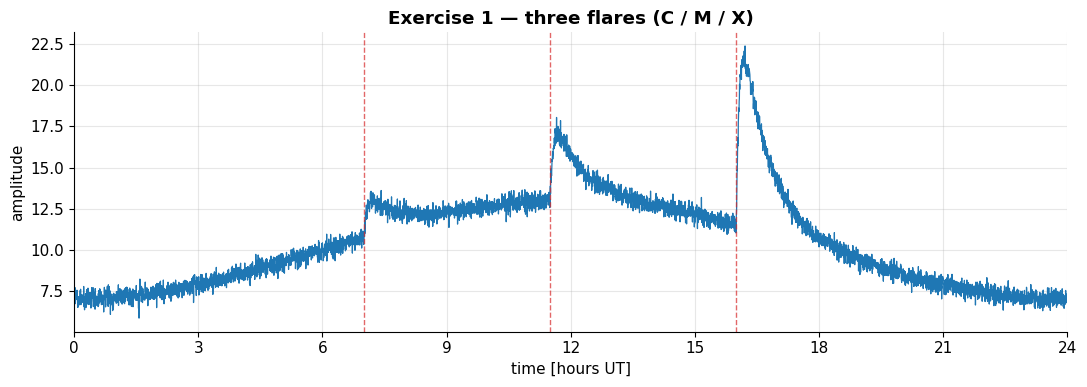

In [10]:
# TODO: add / change flares and see which the detector recovers.
my_flares = [(7.0, 3.0), (11.5, 6.0), (16.0, 15.0)]   # (hour, strength)
h3, s3, true3 = simulate_vlf_day(flares=my_flares, seed=SEED + 3)
d3 = detect_sids(h3, s3, threshold=5.0)
print(f"true flares    : {', '.join(f'{o:.2f}' for o in true3)}")
print(f"detected (5 s) : {', '.join(f'{o:.2f}' for o in d3.onsets) or '(none)'}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(h3, s3, color="#1f77b4", lw=0.9)
for o in true3:
    ax.axvline(o, color="#d62728", ls="--", lw=1.0, alpha=0.7)
ax.set_xlabel("time [hours UT]"); ax.set_ylabel("amplitude")
ax.set_title("Exercise 1 — three flares (C / M / X)")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
plt.tight_layout(); plt.show()


<details><summary>Solution</summary>

The starter cell already builds the three-flare day; we just read the result. At a fixed `threshold=5.0`, the detector recovers the **M-class** (`amplitude 6` at 11.5 h) and **X-class** (`15` at 16.0 h) flares but **misses the weak C-class** (`3` at 7.0 h) — a 3-unit jump barely clears `5σ` above the noise, so it stays hidden. Lowering the threshold is what brings it back (Exercise 2). To make "did the weakest survive?" explicit, match each true onset to its nearest detection:

```python
my_flares = [(7.0, 3.0), (11.5, 6.0), (16.0, 15.0)]   # (hour, C/M/X strength)
h3, s3, true3 = simulate_vlf_day(flares=my_flares, seed=SEED + 3)
d3 = detect_sids(h3, s3, threshold=5.0)

for onset, strength in my_flares:
    if d3.onsets.size and np.min(np.abs(d3.onsets - onset)) < 0.25:
        nearest = d3.onsets[np.argmin(np.abs(d3.onsets - onset))]
        print(f"  flare {strength:4.1f} at {onset:5.2f} h  ->  detected {nearest:5.2f} h")
    else:
        print(f"  flare {strength:4.1f} at {onset:5.2f} h  ->  MISSED")
```

Expected output:

```
  flare  3.0 at  7.00 h  ->  MISSED
  flare  6.0 at 11.50 h  ->  detected 11.56 h
  flare 15.0 at 16.00 h  ->  detected 16.03 h
```

**Takeaway:** detection is a function of flare *strength* relative to the noise floor, not just of the threshold. At `5σ` the weakest (C-class) flare is lost — which is exactly the sensitivity/false-alarm trade-off Exercise 2 explores.

</details>

### Exercise 2 — Threshold vs truth

Take the three-flare day from Exercise 1 and **sweep the threshold** from 2 to 10
sigma. For each, count detections and (where possible) match them to the true
onsets, printing the timing error in minutes. Find the threshold band that
recovers all three flares with **no** false alarms. How does it compare to the
quiet-day test in Section 4?

In [11]:
# TODO: sweep threshold over the Exercise-1 day; match detected to true.
print(f"{'thr':>5} {'# det':>6}   detected onsets (h)")
for thr in (2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0):
    d = detect_sids(h3, s3, threshold=thr)
    onsets_str = ", ".join(f"{o:.2f}" for o in d.onsets) if d.count else "(none)"
    print(f"{thr:5.1f} {d.count:6d}   {onsets_str}")


  thr  # det   detected onsets (h)
  2.0     18   0.83, 1.59, 3.44, 4.39, 6.10, 7.06, 9.97, 10.51, 11.52, 13.93, 16.02, 18.37, 19.75, 20.40, 21.21, 22.05, 22.57, 23.12
  3.0      4   7.10, 11.55, 15.16, 16.02
  4.0      3   7.16, 11.55, 16.03
  5.0      2   11.56, 16.03
  6.0      2   11.59, 16.03
  8.0      2   11.62, 16.04
 10.0      2   11.66, 16.05


<details><summary>Solution</summary>

Extend the starter sweep so that, for each threshold, we match every detection to the nearest true onset, print the timing error in minutes, and flag the case that recovers **all three** flares with **no** spurious extras:

```python
print(f"{'thr':>5} {'# det':>6}  {'clean (3, no extras)':>22}   timing errors [min]")
for thr in (2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0):
    d = detect_sids(h3, s3, threshold=thr)
    errs = []
    for onset, _ in my_flares:
        if d.onsets.size and np.min(np.abs(d.onsets - onset)) < 0.25:
            nearest = d.onsets[np.argmin(np.abs(d.onsets - onset))]
            errs.append(abs(nearest - onset) * 60)
    clean = (d.count == 3 and len(errs) == 3)
    errs_str = ", ".join(f"{e:.1f}" for e in errs) if errs else "(none matched)"
    print(f"{thr:5.1f} {d.count:6d}  {str(clean):>22}   {errs_str}")
```

Expected output:

```
  thr  # det    clean (3, no extras)   timing errors [min]
  2.0     18                   False   3.8, 1.0, 1.2
  3.0      4                   False   6.0, 2.7, 1.2
  4.0      3                    True   9.7, 3.0, 1.7
  5.0      2                   False   3.8, 1.7
  6.0      2                   False   5.5, 1.7
  8.0      2                   False   7.3, 2.5
 10.0      2                   False   9.5, 3.0
```

**Takeaway:** only **`threshold = 4σ`** is clean here — it is the *single* value that catches the weak C-class flare while rejecting noise. Below it (2–3σ) noise bumps sneak in as spurious events; above it (≥5σ) the weak flare drops out and you are left with just the M and X events. That clean band is far narrower than the two-flare day of Section 4 (which tolerated 4–8σ), precisely because the weak C-class flare forces the threshold down toward the noise. The quiet-day test still passes at 5σ — but on *this* day, 5σ is already too high to see everything.

</details>

### Exercise 3 — A deeper (or shallower) diurnal swing

The `diurnal_amp` parameter sets how strongly the D-layer swings between day and
night — it depends on your transmitter, your path, and the season. Re-run a day
with a **large** `diurnal_amp` (e.g. 8) and a **small** one (e.g. 1), at the
*same* noise and flares. Confirm that `detect_sids` still recovers the flares in
**both** cases — that is the point of de-trending: the detector keys on the *fast*
spikes, not the slow baseline, so a deeper day/night swing should not fool it.

In [12]:
# TODO: vary diurnal_amp and confirm detection is robust to the baseline depth.
for damp in (1.0, 3.0, 8.0):
    h, s, tr = simulate_vlf_day(flares=FLARES, diurnal_amp=damp,
                                noise=0.3, seed=SEED + 4)
    d = detect_sids(h, s, threshold=5.0)
    matched = all(
        d.onsets.size and np.min(np.abs(d.onsets - o)) < 0.25 for o in tr
    )
    print(f"diurnal_amp={damp:4.1f}  ->  {d.count} detected, "
          f"both flares found: {matched}")


diurnal_amp= 1.0  ->  2 detected, both flares found: True
diurnal_amp= 3.0  ->  2 detected, both flares found: True
diurnal_amp= 8.0  ->  2 detected, both flares found: True


<details><summary>Solution</summary>

The starter cell already loops over `diurnal_amp`; the point is to confirm the answer and understand *why* it holds. Hold the flares and noise fixed and only change the depth of the day/night swing, then check both flares are still recovered:

```python
for damp in (1.0, 3.0, 8.0):
    h, s, tr = simulate_vlf_day(flares=FLARES, diurnal_amp=damp,
                                noise=0.3, seed=SEED + 4)
    d = detect_sids(h, s, threshold=5.0)
    both = all(d.onsets.size and np.min(np.abs(d.onsets - o)) < 0.25 for o in tr)
    print(f"diurnal_amp={damp:4.1f}  ->  {d.count} detected, both flares found: {both}")
```

Expected output:

```
diurnal_amp= 1.0  ->  2 detected, both flares found: True
diurnal_amp= 3.0  ->  2 detected, both flares found: True
diurnal_amp= 8.0  ->  2 detected, both flares found: True
```

**Takeaway:** the detector is **robust to baseline depth** — all three swings recover both flares with no false alarms. That is the whole purpose of the running-median de-trending in `detect_sids`: the median tracks the *slow* diurnal hump (whatever its amplitude) and subtracts it away, so only the *fast* flare spikes survive to be thresholded. A deeper day/night swing simply gives the median a bigger curve to follow; it does not leak into the residual, so it cannot fool the threshold. Contrast this with thresholding the **raw** signal, where a deep daytime hump would itself trip a fixed cutoff.

</details>

## Recap

- **VLF (3–30 kHz)** waves are trapped in the **Earth–ionosphere waveguide**,
  bouncing between the ground and the ionospheric **D-layer**, so a single navy
  beacon (NAA, NWC, GQD, …) can be heard thousands of km away. Its received
  amplitude is a free, continuous **readout of the D-layer overhead**.
- The D-layer is made by **solar UV/X-rays**, so the amplitude breathes with a
  smooth **diurnal** cycle — firm by day, fading at night, swinging at the
  terminator. `simulate_vlf_day` reproduces that baseline plus noise.
- A **solar flare**'s X-rays suddenly over-ionise the D-layer, producing a
  **sudden ionospheric disturbance**: a **fast rise, slow recovery** spike
  (`sid_profile`). This is the *same* flare that drives the solar radio bursts of
  [Chapter 23](23_solar_and_jupiter.ipynb) — two fingerprints of one event.
- To **detect** flares (`detect_sids`), **de-trend** the slow diurnal baseline
  with a running median, then **threshold** the residual; the threshold trades
  sensitivity against false alarms, and a quiet day correctly yields **zero**
  detections. SuperSID observers contribute these timings to space-weather
  networks.
- The VLF band also carries **natural radio** — sferics, tweeks, and
  **whistlers** — lightning energy guided along the waveguide and field lines, the
  domain of the **INSPIRE** project.
- This is genuine, low-cost, **receive-only** (no-licence) science you can run
  indoors 24/7: see [Projects, Kits & Hacks](../docs/projects.md#vlf-the-ionosphere)
  for the SuperSID and INSPIRE kits, and the
  [field notes](../docs/field-notes.md) for the amateur wisdom behind it.

### What's next

You now have two ground-based windows on the **same Sun**: the **VLF/SuperSID**
view of a flare's X-rays hitting our own ionosphere (this chapter) and the
**~20 MHz / Radio JOVE** view of the flare's bursts and CME shocks in the corona
([Chapter 23](23_solar_and_jupiter.ipynb)). Watch both during one flare and you
are doing **multi-instrument space-weather monitoring** from a desk — the amateur
end of the same enterprise that protects satellites and power grids.